# Évaluation du pipeline complet : OLS quotidien → désagrégation horaire

Ce notebook évalue la chaîne de reconstruction complète :

1. **OLS quotidien** (`baseline_electricity_model.py`) — entraînement + évaluation journalière  
2. **Diagnostic saisonnalité** — vérifie l'absence de biais résiduel dans le temps  
3. **Profils horaires** (`hourly_disaggregation.py`) — appris sur l'historique  
4. **Reconstruction horaire régionale** — prédictions OLS désagrégées × profils  
5. **Agrégation nationale** — évaluation finale MWh/h

## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from baseline_electricity_model import (
    run_pipeline_v2, get_school_holidays,
    predict_demand, evaluate_predictions,
    plot_predictions_vs_actual, plot_residuals_seasonality,
    plot_daily_residuals_vs_temperature,
    summarize_model_stats,
)
from hourly_disaggregation import (
    load_hourly_data, compute_profiles,
    disaggregate_all_regions,
    evaluate_disaggregation,
    plot_profiles, plot_week_comparison,
    compute_residuals, plot_residuals_vs_temperature,
)

In [2]:
# ── Chemins ──────────────────────────────────────────────────────────────────
CONSO_DAILY_PATH  = "base_data/FR_elec/conso_reg_daily.csv"
TEMP_DAILY_PATH   = "base_data/temp_era/temp_FR_daily_era.csv"
CONSO_HOURLY_PATH = "base_data/FR_elec/conso_reg_hourly.csv"   # ← à ajuster

# ── Paramètres OLS ───────────────────────────────────────────────────────────
TRAIN_YEARS  = list(range(2016, 2025))   # 2016–2024, COVID inclus (exclu via flag)
EVAL_YEAR    = 2025                       # année d'évaluation out-of-sample
ALPHA_HDD    = 0.4
ALPHA_CDD    = 0.6
MONTH_EFFECT = False

_, region_zone_map = get_school_holidays(list(range(2010, 2026)))

## Étape 1 — Prédiction de la demande quotidienne (OLS)

In [3]:
models, baselines, calendar_df = run_pipeline_v2(
    CONSO_DAILY_PATH, TEMP_DAILY_PATH,
    training_period=TRAIN_YEARS,
    exclude_full_covid_y=False,
    alpha=ALPHA_HDD,
    alpha_cdd=ALPHA_CDD,
    month_effect=MONTH_EFFECT,
)

[load_data] Période retenue : 2016-01-01 → 2024-12-31
[load_data] Régions : ['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire', 'Grand Est', 'Hauts-de-France', 'Normandie', 'Nouvelle-Aquitaine', 'Occitanie', 'Pays de la Loire', "Provence-Alpes-Côte d'Azur", 'Île-de-France']
[load_data] N jours : 2831

[calendar] Génération des variables calendaires...
[calendar] 29 variables générées

=== ESTIMATION OLS V2 PAR RÉGION ===

  Calendrier       : v2 (sat+pont, vac décomposées, début-août)
  Température HDD  : T_eff(alpha=0.4)
  Température CDD  : T_eff(alpha=0.6)
  Années exclues   : {'Auvergne-Rhône-Alpes': 'A', 'Bourgogne-Franche-Comté': 'A', 'Nouvelle-Aquitaine': 'A', 'Centre-Val de Loire': 'B', 'Île-de-France': 'C', 'Normandie': 'B', 'Hauts-de-France': 'B', 'Bretagne': 'B', 'Pays de la Loire': 'B', 'Grand Est': 'B', 'Occitanie': 'C', "Provence-Alpes-Côte d'Azur": 'B', 'Corse': 'B'}

Région                                  R²  R²adj     RMSE   Tc1   Tc

In [4]:
# Résumé des performances in-sample
summarize_model_stats(models)[["R2", "R2_adj", "RMSE", "T_c1_°C", "T_c2_°C"]]

,R2,R2_adj,RMSE,T_c1_°C,T_c2_°C
region,,,,,
Auvergne-Rhône-Alpes,0.9578,0.9576,297.08,12.5,17.5
Bourgogne-Franche-Comté,0.9567,0.9564,104.28,14.5,20.0
Bretagne,0.9442,0.9439,141.06,14.5,21.0
Centre-Val de Loire,0.9415,0.9412,122.91,15.0,20.0
Grand Est,0.9483,0.9480,213.62,14.5,19.0
Hauts-de-France,0.9311,0.9308,257.96,14.5,18.5
Normandie,0.9518,0.9516,146.34,14.0,20.5
Nouvelle-Aquitaine,0.9622,0.9620,199.85,15.0,20.0
Occitanie,0.9637,0.9635,172.17,13.0,19.5


### 1b. Diagnostic saisonnalité des résidus

Trois graphiques pour vérifier qu'il ne reste pas de structure saisonnière non capturée :
- **(1) Par mois** : biais saisonnier résiduel → toutes les boîtes devraient être centrées sur 0
- **(2) Par année** : dérive structurelle non captée par `post_rupture`
- **(3) Heatmap mois × année** : localise précisément les anomalies

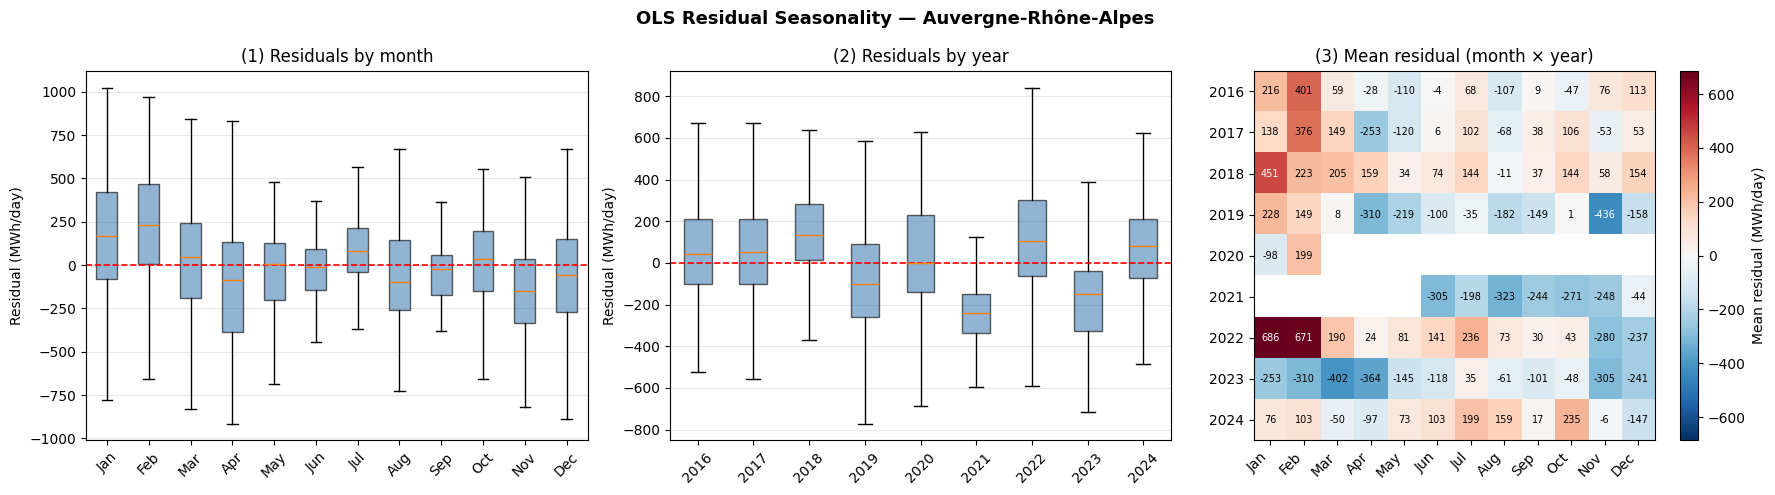

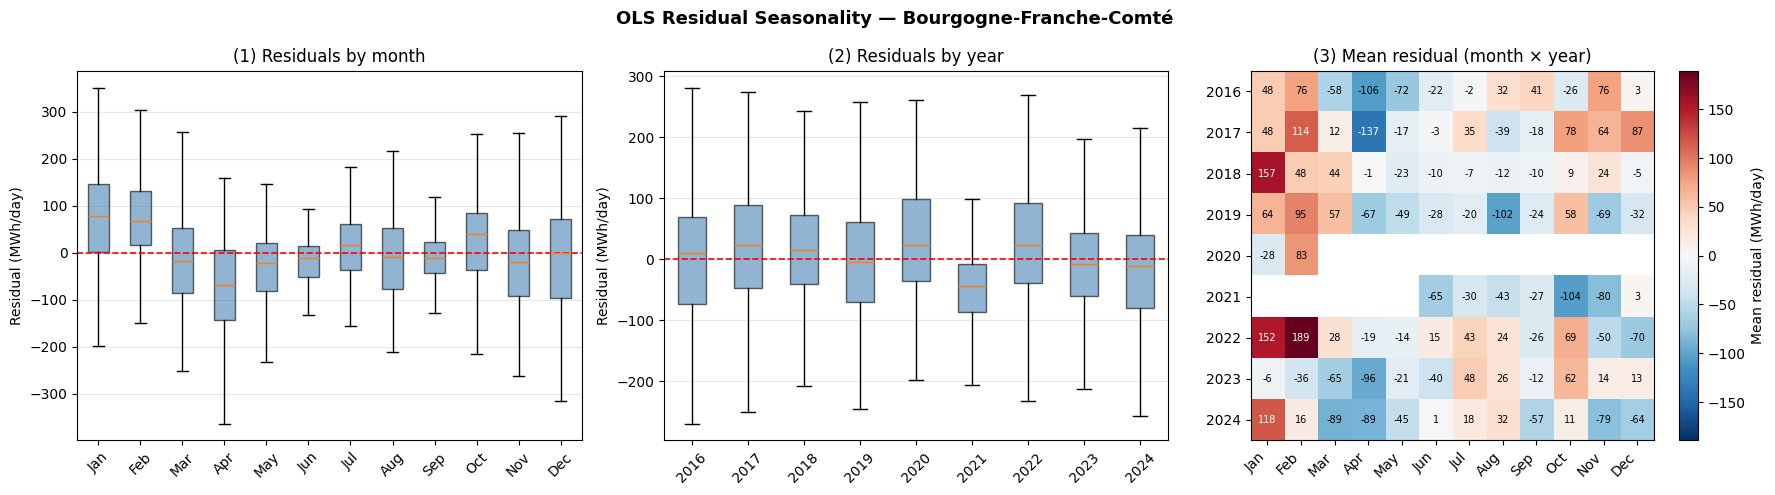

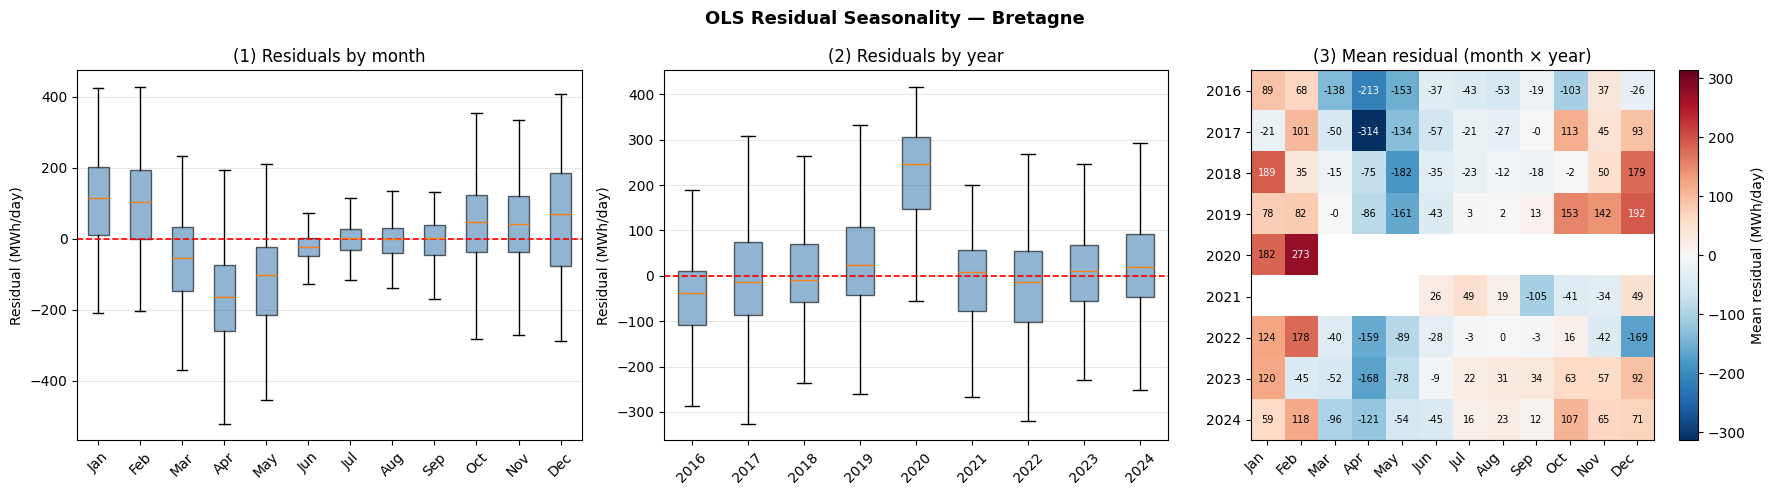

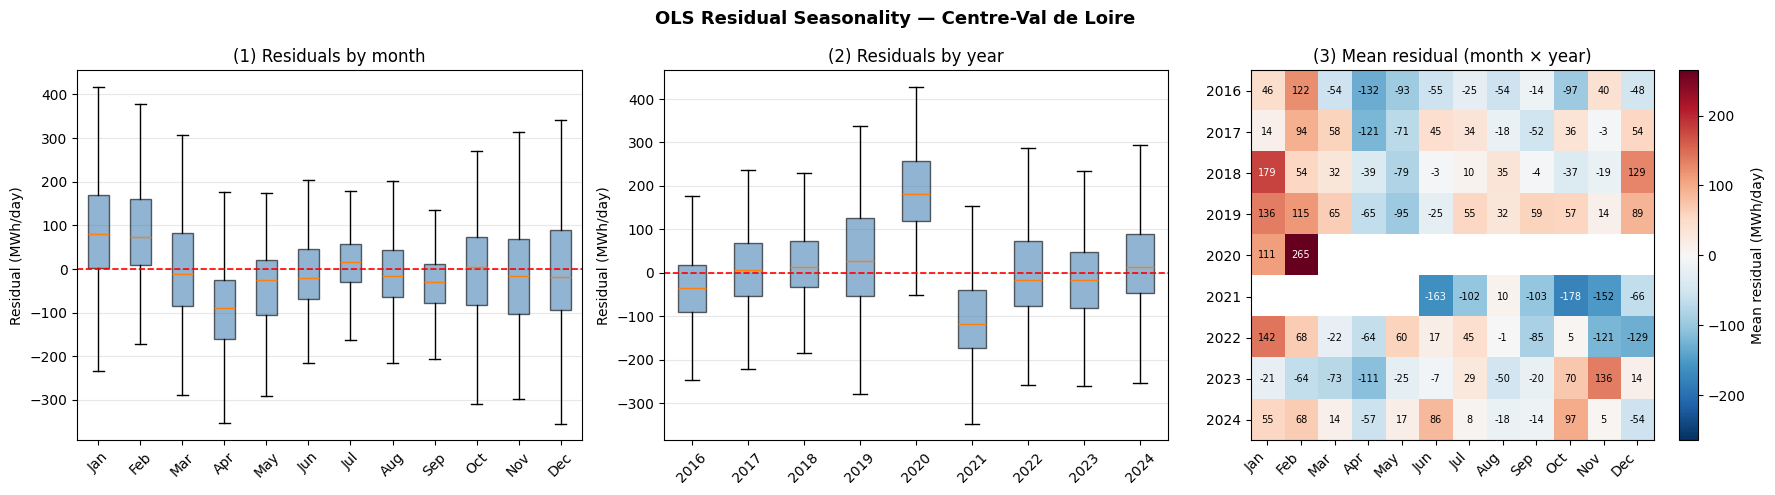

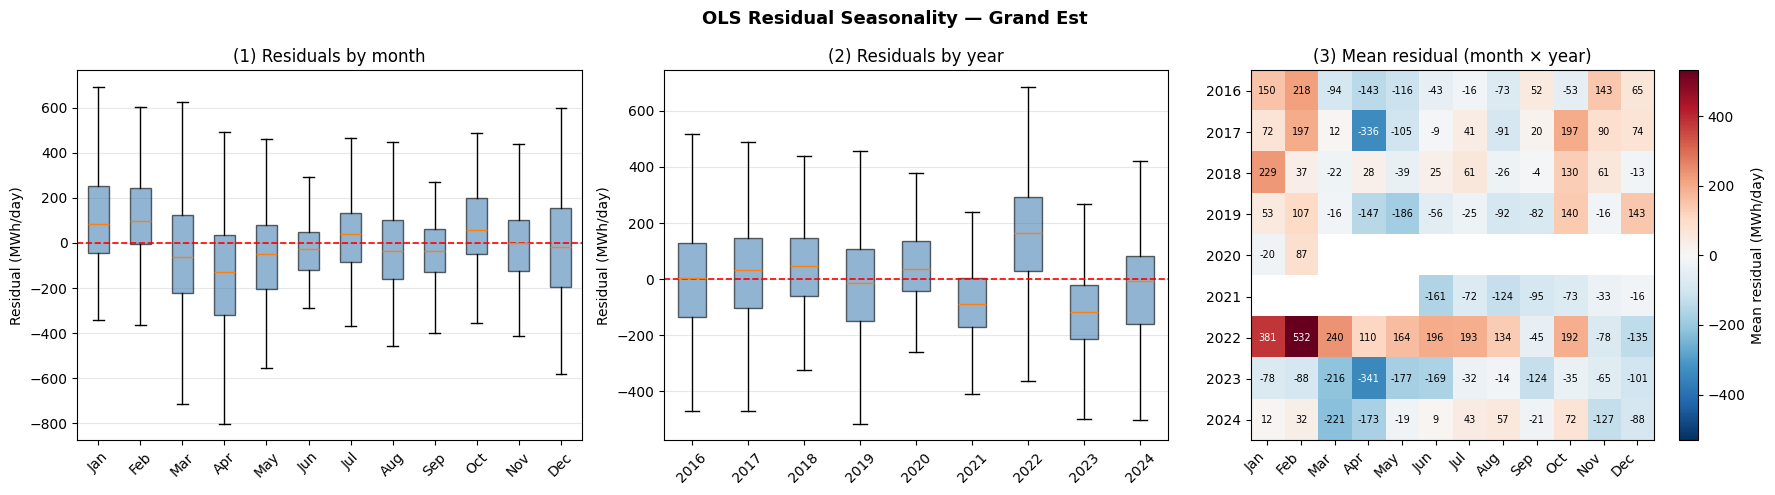

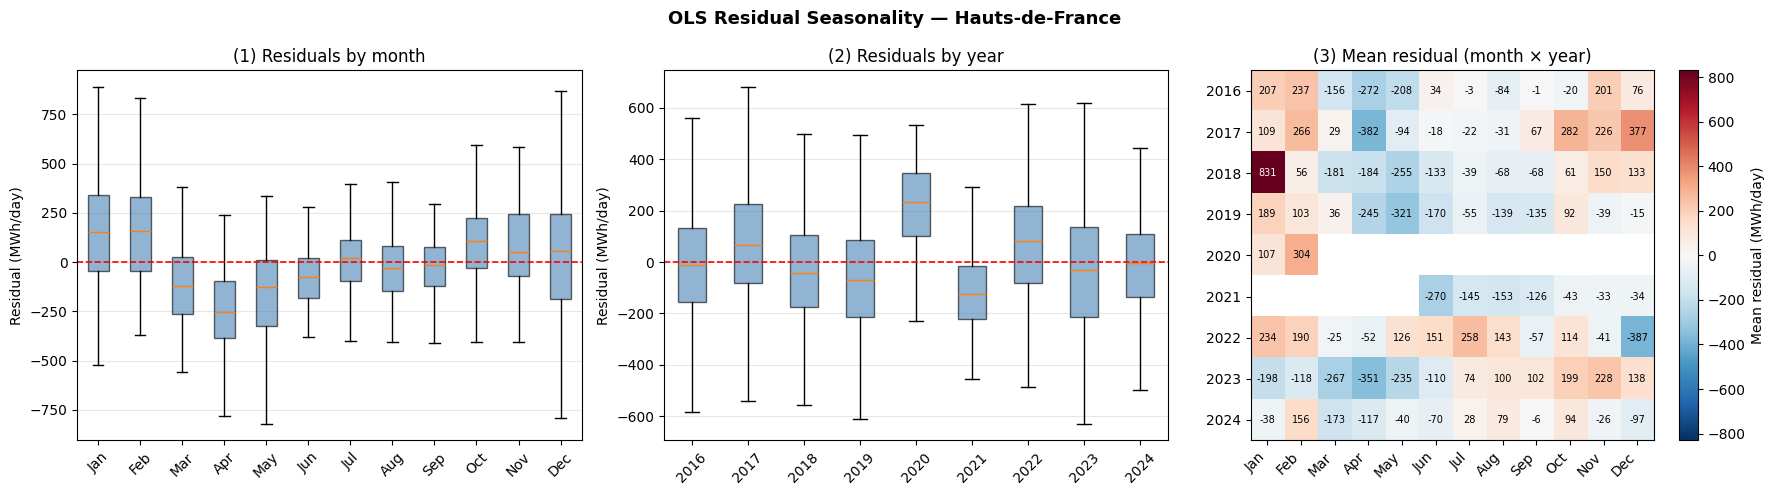

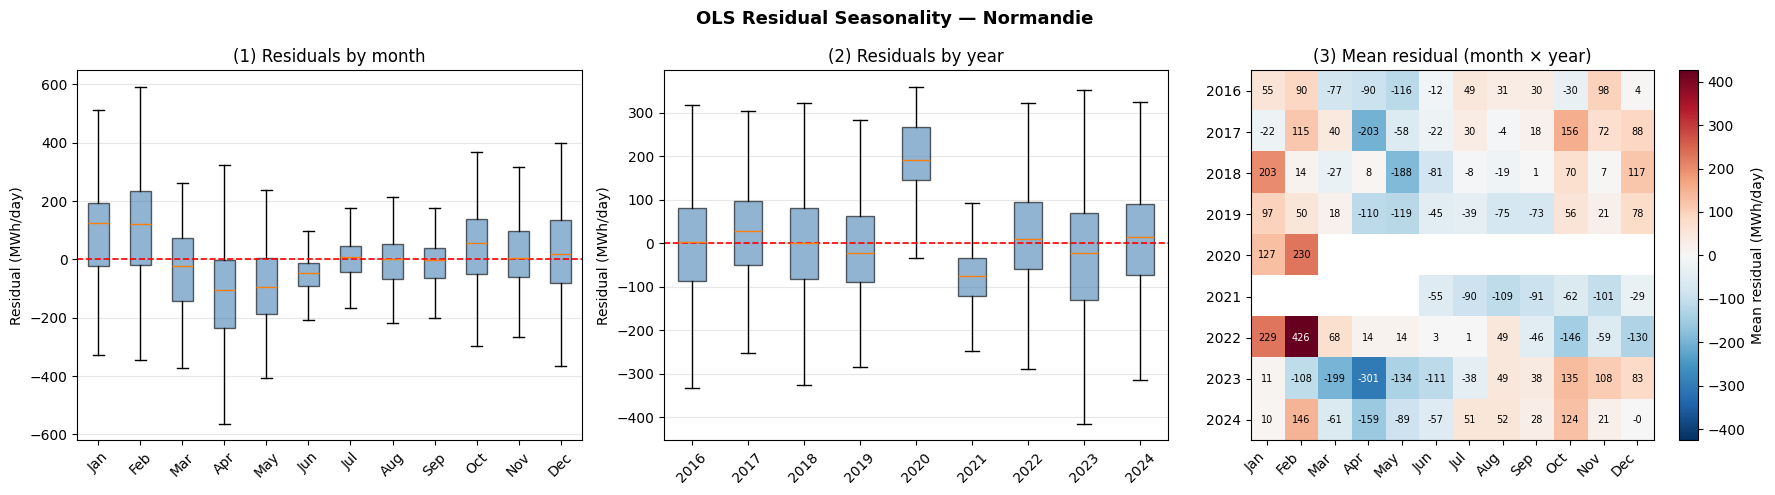

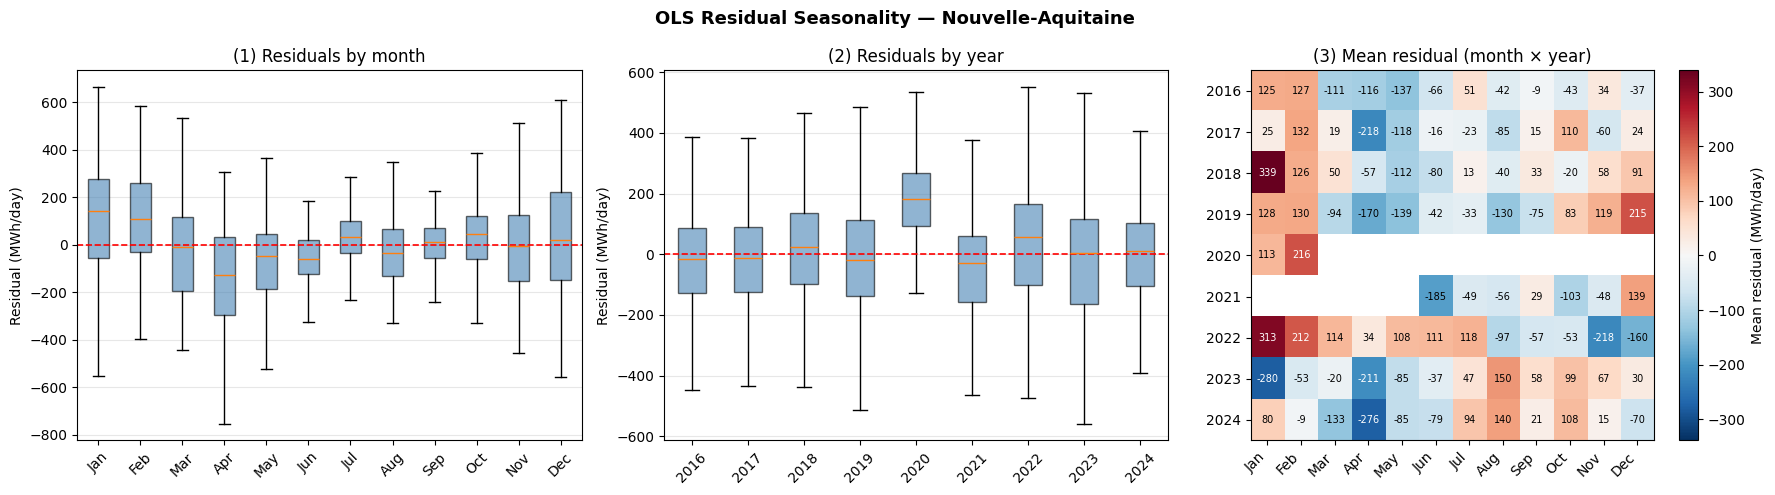

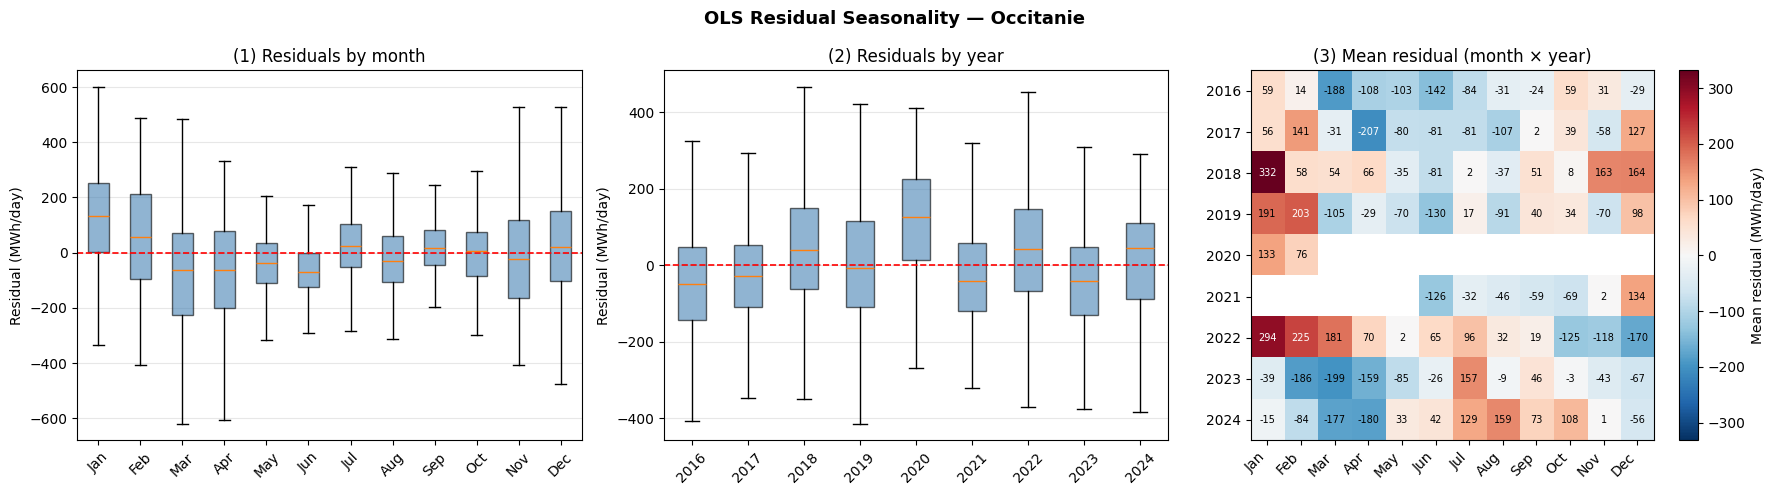

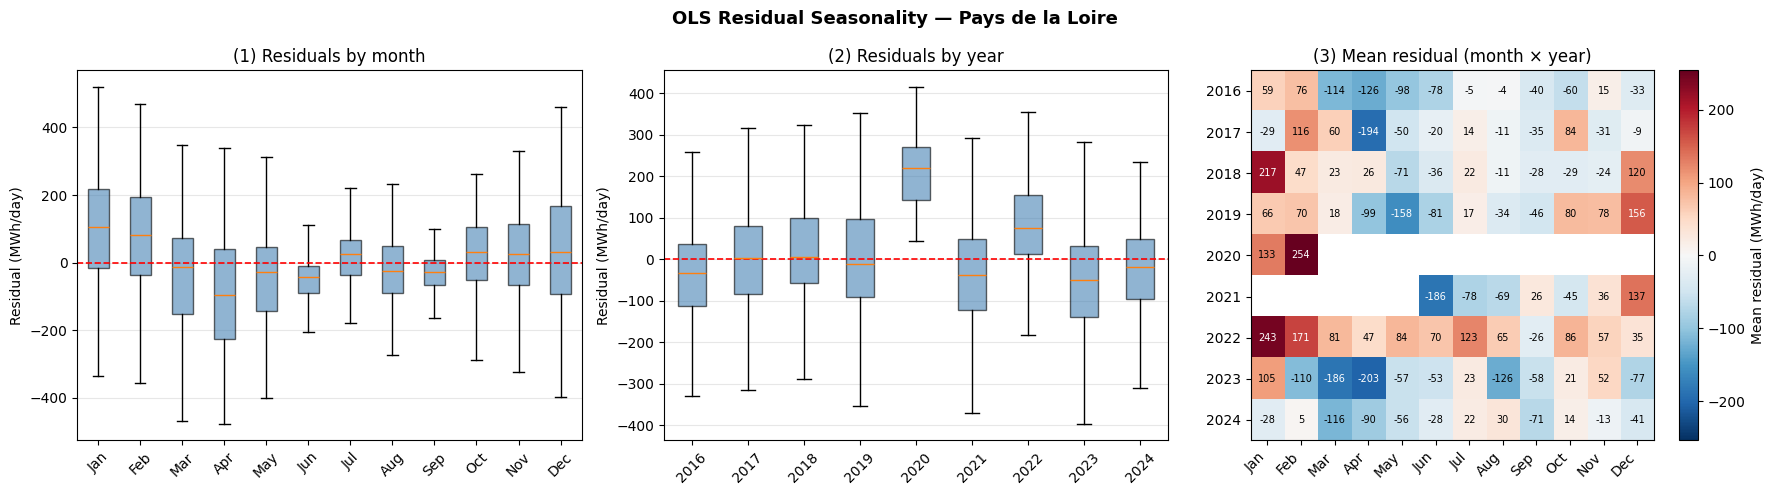

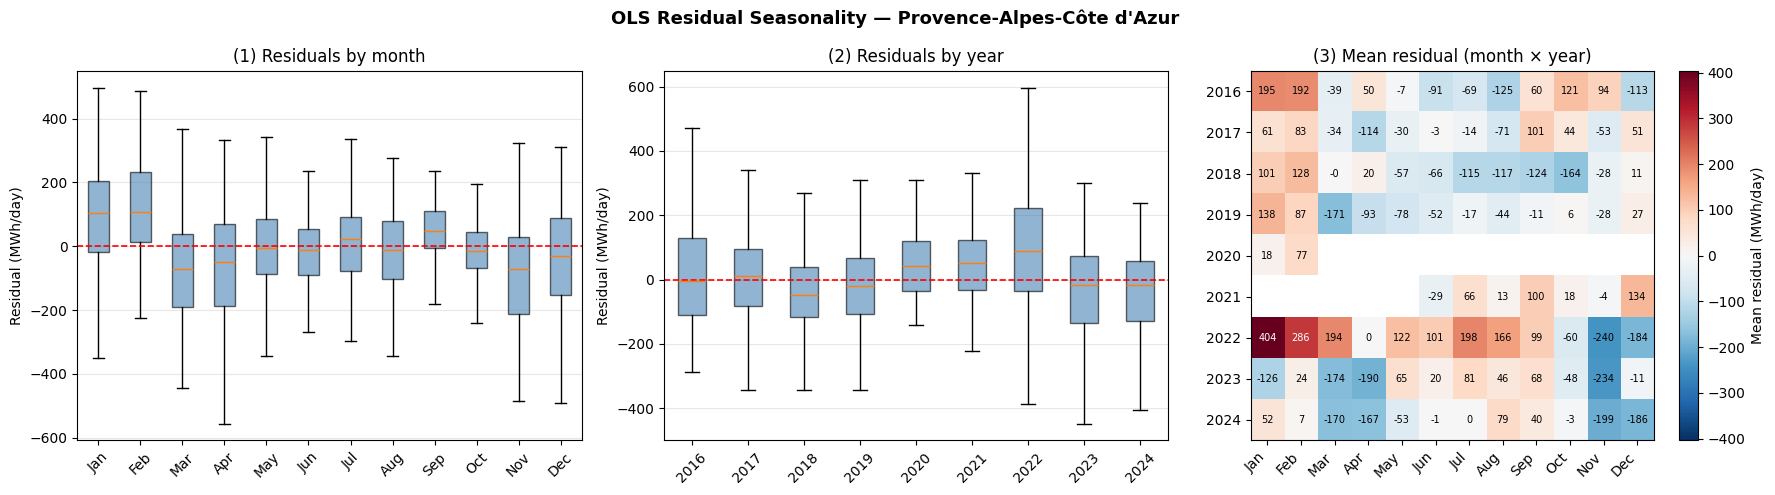

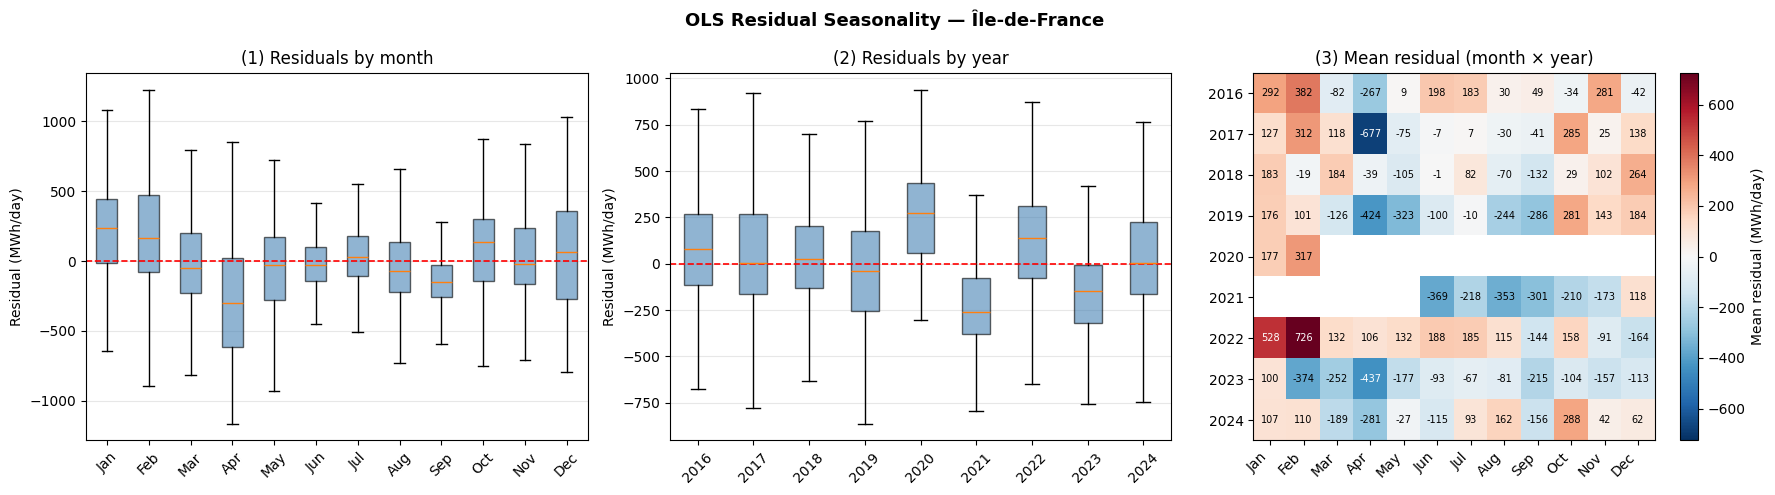

In [5]:
for region in models:
    plot_residuals_seasonality(models[region]["results"], region, save=False)

### 1c. Temperature residual analysis (daily OLS)

After the OLS has removed the HDD/CDD temperature effect, is there still a temperature signal in the residuals?

- **(1)** Scatter resid vs T + 1°C-bin mean: a flat cloud around 0 means the PWL model captured the temperature shape well. A visible trend reveals remaining non-linearity (wrong breakpoint, asymmetry between cold and hot, etc.).
- **(2)** MAE by temperature bin: where does the model struggle most — mild days, cold waves, heat waves?
- **(3)** Heatmap mean residual (month × T): checks for month-temperature interactions not captured by the HDD/CDD specification.

> The R² shown in each panel (1) title quantifies how much residual variance is still explained by temperature after the OLS correction.

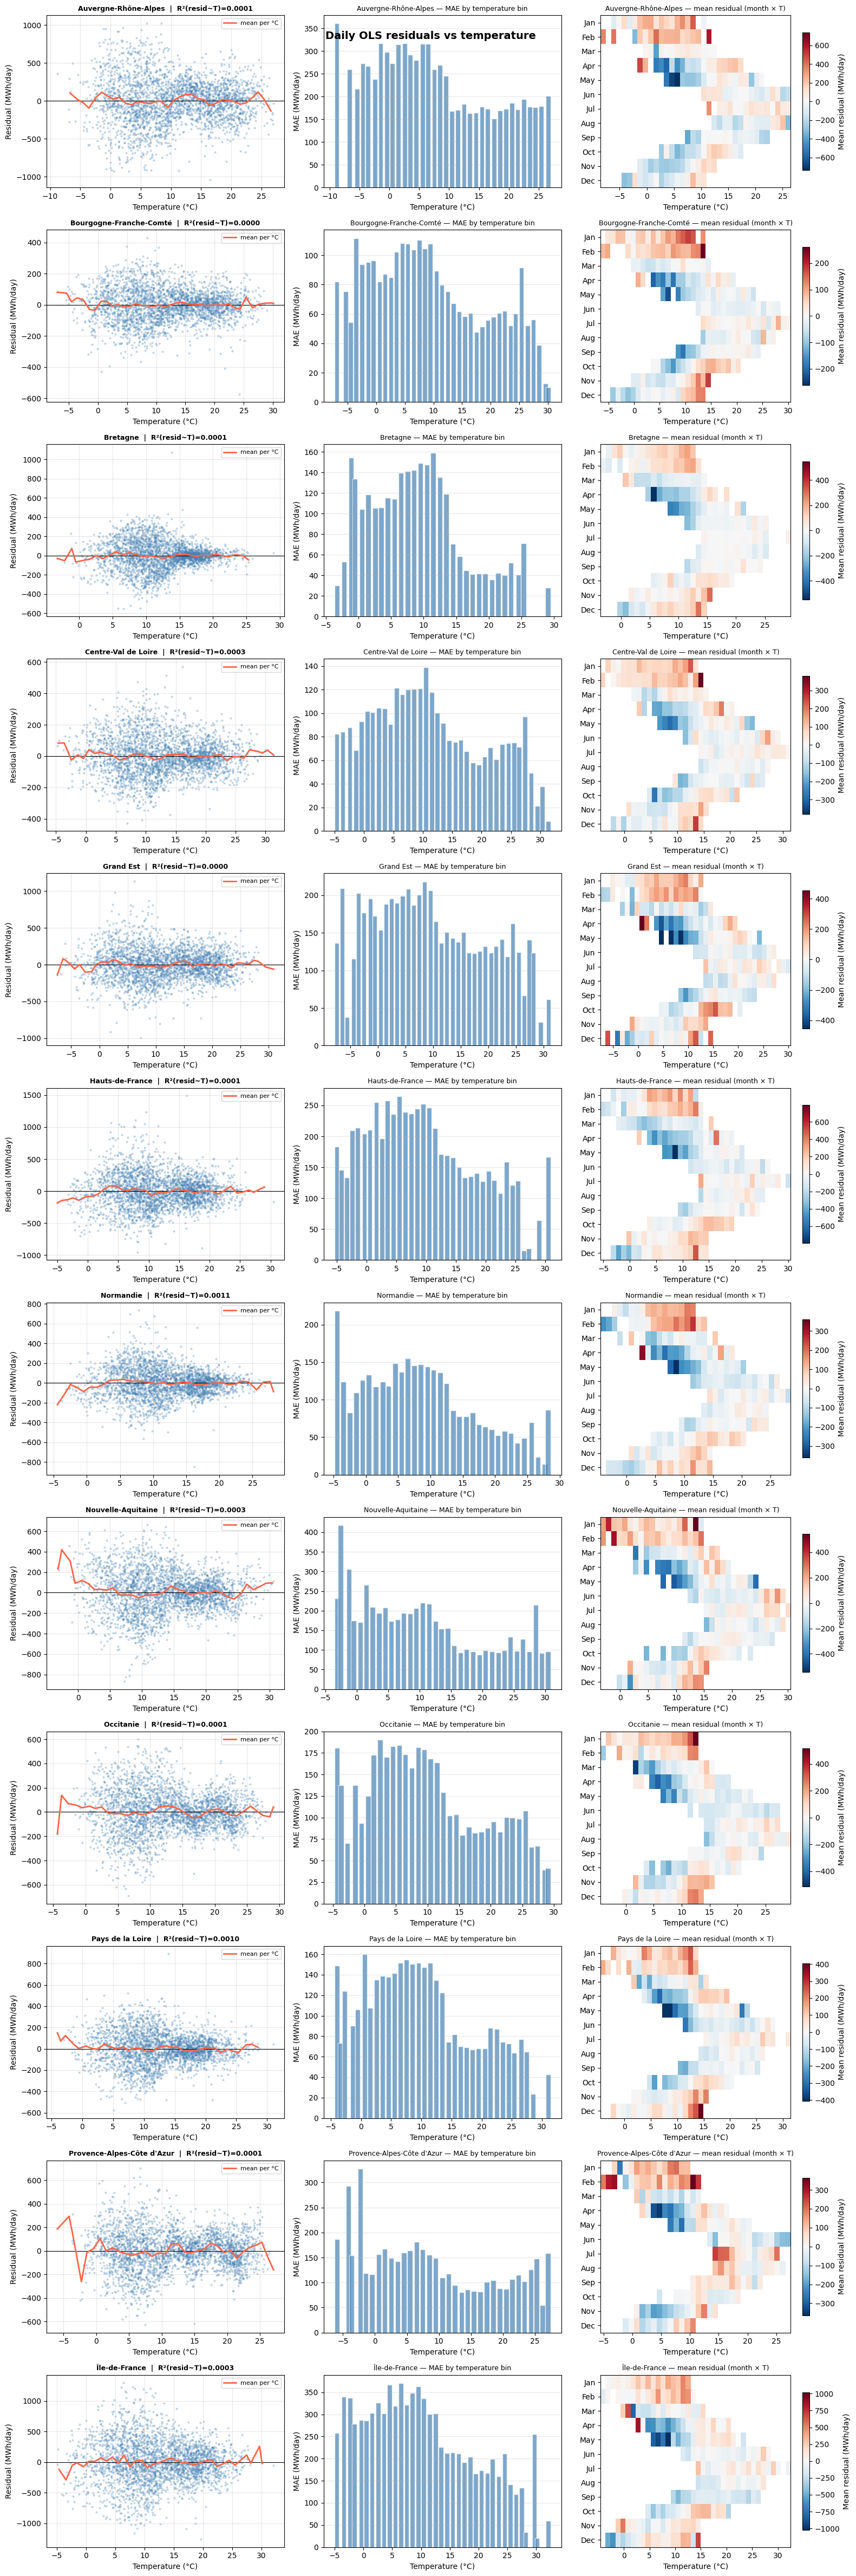

In [6]:
# Load daily temperatures (also reused in step 2 below)
temp = pd.read_csv(TEMP_DAILY_PATH, index_col=0, parse_dates=True)

# Plots 3 panels per region: scatter resid vs T, MAE by T-bin, heatmap month×T
plot_daily_residuals_vs_temperature(models, temp)

## Étape 2 — Évaluation quotidienne out-of-sample

In [7]:
conso_daily = pd.read_csv(CONSO_DAILY_PATH, index_col=0, parse_dates=True)
# temp is already loaded in section 1c above

# Out-of-sample daily predictions
df_pred_daily = {}
for r in models:
    df_pred_daily[r] = predict_demand(
        models[r], r, region_zone_map,
        temp[r].loc[str(EVAL_YEAR)]
    )

In [8]:
# Évaluation régionale (journalier)
rows = []
for r in df_pred_daily:
    m = evaluate_predictions(
        conso_daily[r].loc[str(EVAL_YEAR)],
        df_pred_daily[r]["y_pred"],
        label=f"{r} {EVAL_YEAR}",
    )
    rows.append(m.rename(r))

metrics_daily = pd.DataFrame(rows)
print(f"\n=== Évaluation journalière — {EVAL_YEAR} ===")
metrics_daily

[eval] Auvergne-Rhône-Alpes 2025
  RMSE  :        242 MWh/j
  nRMSE :       3.40 %
  MAE   :        184 MWh/j
  MAPE  :       2.62 %
  N     :        365 jours
[eval] Bourgogne-Franche-Comté 2025
  RMSE  :        126 MWh/j
  nRMSE :       5.63 %
  MAE   :         96 MWh/j
  MAPE  :       4.41 %
  N     :        365 jours
[eval] Bretagne 2025
  RMSE  :        132 MWh/j
  nRMSE :       5.30 %
  MAE   :         98 MWh/j
  MAPE  :       3.90 %
  N     :        365 jours
[eval] Centre-Val de Loire 2025
  RMSE  :        122 MWh/j
  nRMSE :       6.01 %
  MAE   :         95 MWh/j
  MAPE  :       4.85 %
  N     :        365 jours
[eval] Grand Est 2025
  RMSE  :        214 MWh/j
  nRMSE :       4.46 %
  MAE   :        167 MWh/j
  MAPE  :       3.61 %
  N     :        365 jours
[eval] Hauts-de-France 2025
  RMSE  :        209 MWh/j
  nRMSE :       3.91 %
  MAE   :        165 MWh/j
  MAPE  :       3.11 %
  N     :        365 jours
[eval] Normandie 2025
  RMSE  :        163 MWh/j
  nRMSE :       5

,RMSE,nRMSE_%,MAE,MAPE_%,N_jours
Auvergne-Rhône-Alpes,242.2,3.40,184.3,2.62,365.0
Bourgogne-Franche-Comté,125.6,5.63,95.6,4.41,365.0
Bretagne,132.3,5.30,97.7,3.90,365.0
Centre-Val de Loire,122.4,6.01,95.2,4.85,365.0
Grand Est,213.9,4.46,166.8,3.61,365.0
Hauts-de-France,208.9,3.91,164.8,3.11,365.0
Normandie,163.4,5.54,128.3,4.34,365.0
Nouvelle-Aquitaine,240.4,5.10,191.4,4.14,365.0
Occitanie,205.9,4.94,160.2,3.86,365.0
Pays de la Loire,138.0,4.74,105.1,3.57,365.0


In [9]:
# Évaluation nationale (journalier)
true_nat_daily = sum(conso_daily[r].loc[str(EVAL_YEAR)] for r in df_pred_daily)
pred_nat_daily = sum(df_pred_daily[r]["y_pred"]         for r in df_pred_daily)
evaluate_predictions(true_nat_daily, pred_nat_daily, label=f"France {EVAL_YEAR}")

[eval] France 2025
  RMSE  :      1,736 MWh/j
  nRMSE :       3.43 %
  MAE   :      1,323 MWh/j
  MAPE  :       2.61 %
  N     :        365 jours


RMSE       1736.10
nRMSE_%       3.43
MAE        1322.80
MAPE_%        2.61
N_jours     365.00
Name: France 2025, dtype: float64

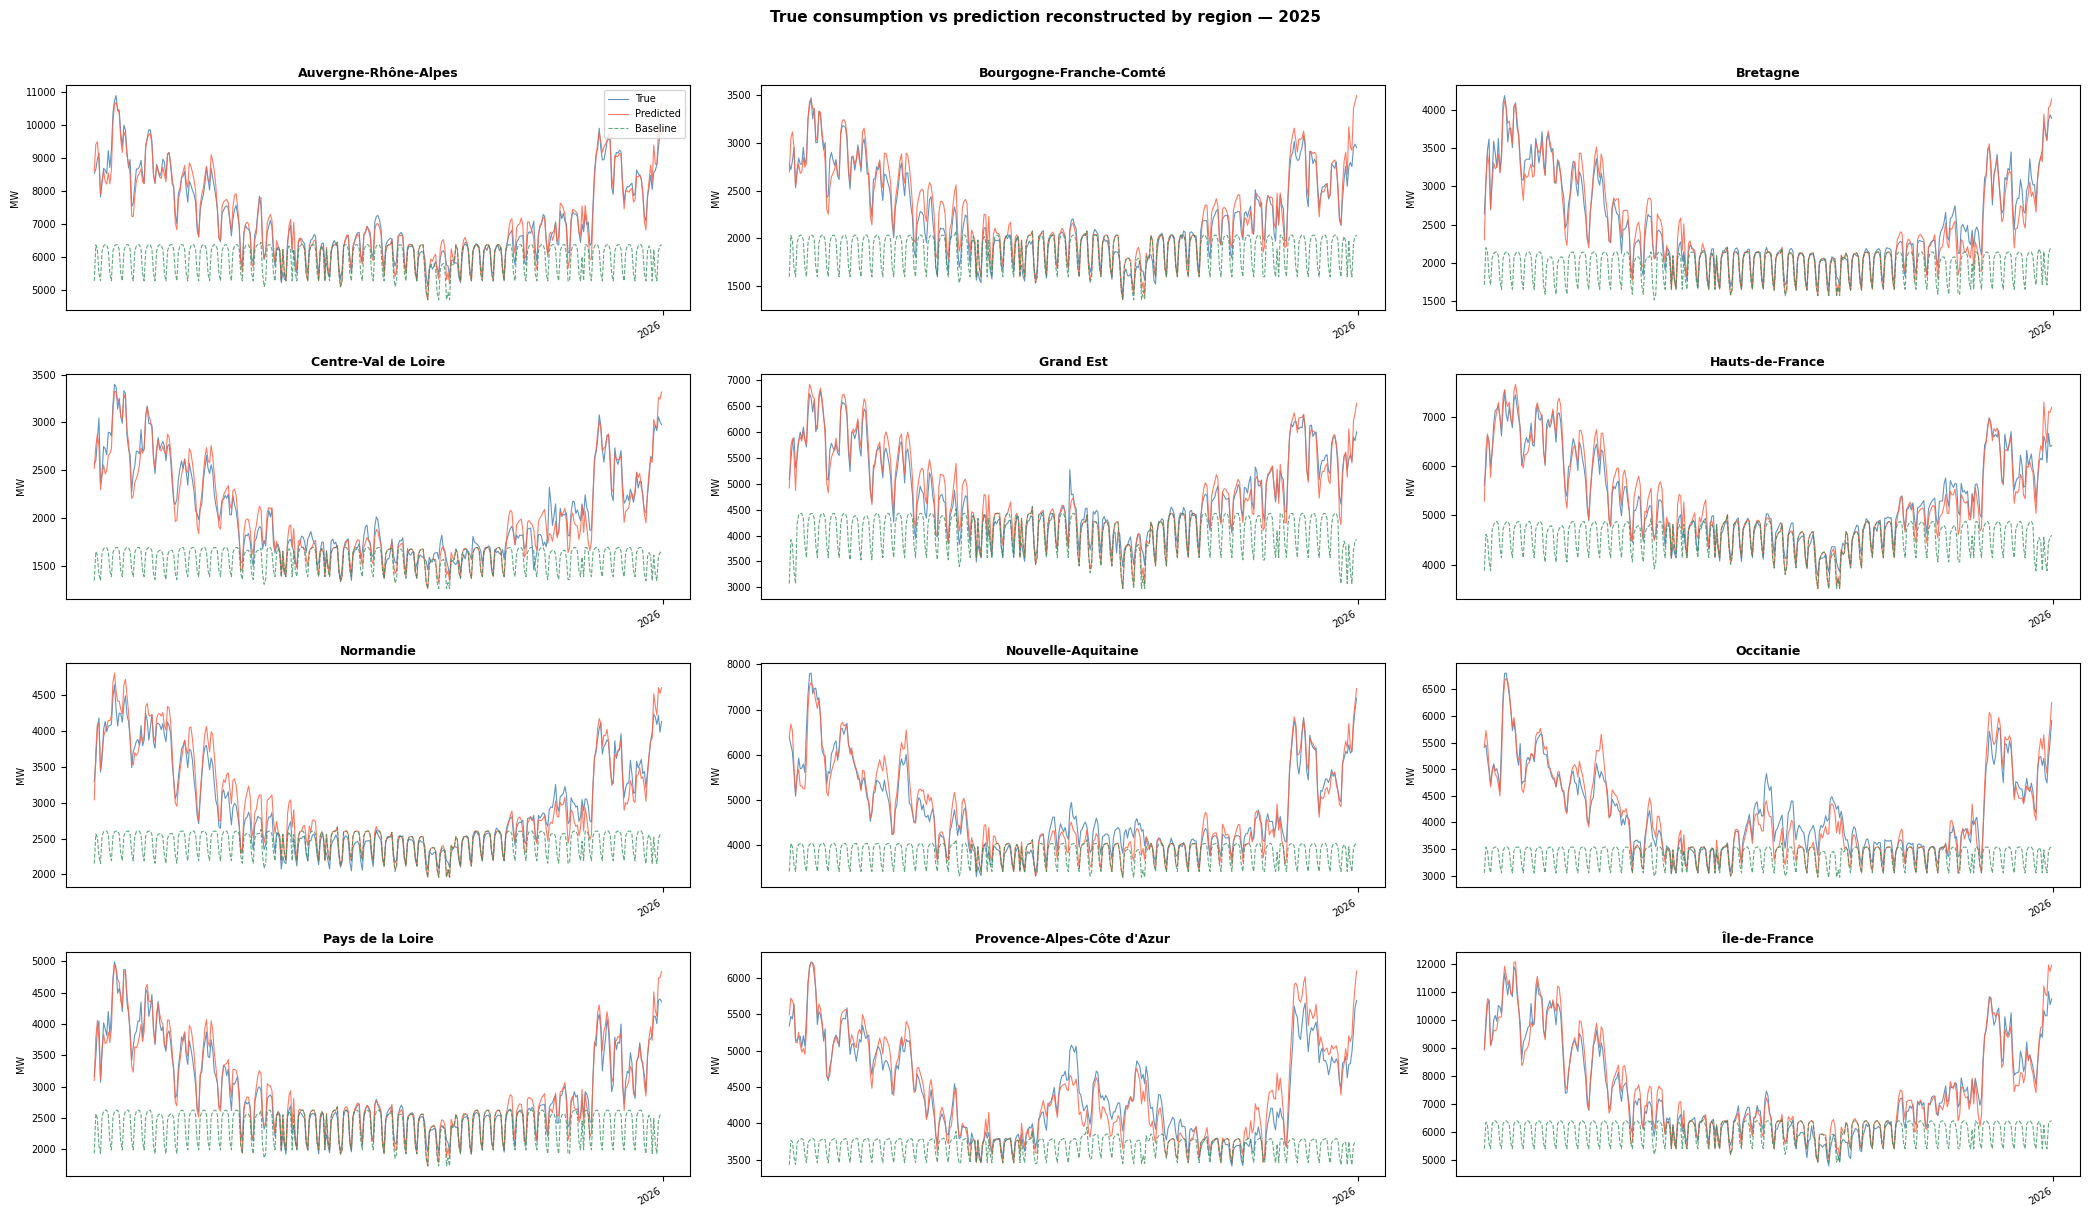

In [10]:
# Graphique prédit vs réel pour quelques régions
plot_predictions_vs_actual(
    models, conso_daily, temp, region_zone_map,
    year=EVAL_YEAR, ncols=3,
)

## Étape 3 — Profils de désagrégation horaire

Les profils sont appris sur l'historique complet (hors COVID).
Chaque profil = part de la conso journalière sur chaque heure,
par combinaison (type_jour × saison).

In [11]:
conso_hourly, _ = load_hourly_data(CONSO_HOURLY_PATH)
profiles = compute_profiles(conso_hourly, exclude_years=[2016,2025])
print(f"\nProfils calculés pour {len(profiles)} régions")
print(f"Combinaisons par région : {next(iter(profiles.values())).shape[0]} (type_jour × saison)")

[load] conso_reg_hourly.csv : 13 timestamp(s) dupliqué(s) retirés (probablement changements d'heure)
[load] Conso : 2013-01-01 00:00:00 → 2026-01-01 23:00:00  |  113,963 lignes  |  12 régions

Profils calculés pour 12 régions
Combinaisons par région : 20 (type_jour × saison)


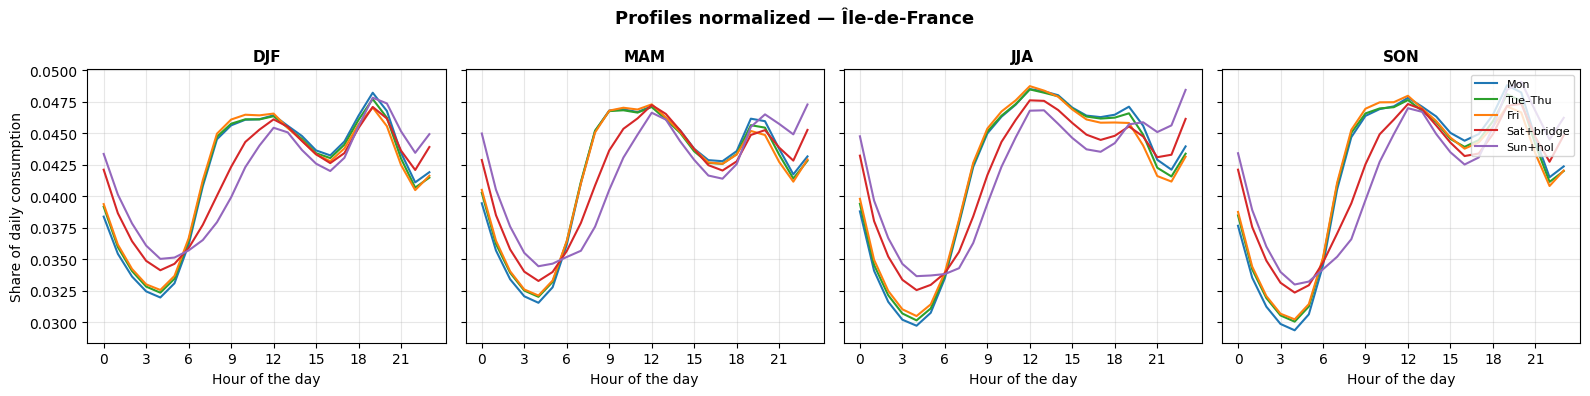

In [12]:
# Visualisation des profils sur une région exemple
plot_profiles(profiles, "Île-de-France")

## Étape 4 — Reconstruction de la demande horaire régionale

On désagrège les prédictions OLS journalières → horaires via les profils.

L'erreur totale = erreur OLS quotidien **+** erreur désagrégation.

In [13]:
# DataFrame journalier des prédictions OLS → désagrégation horaire
# daily predictions are in avg MW; profiles sum to 1 over 24h, so multiply by 24
# to convert avg MW → MWh/day before disaggregation (which then gives MW per hour)
daily_pred_df = pd.DataFrame({
    r: df_pred_daily[r]["y_pred"] * 24
    for r in df_pred_daily
})

hourly_pred = disaggregate_all_regions(daily_pred_df, profiles)
print(f"Hourly demand reconstructed: {hourly_pred.index.min()} → {hourly_pred.index.max()}")
print(f"Shape: {hourly_pred.shape}")

Hourly demand reconstructed: 2025-01-01 00:00:00 → 2025-12-31 23:00:00
Shape: (8760, 12)


In [14]:
# Conso horaire réelle sur l'année d'évaluation
conso_h_eval    = conso_hourly[conso_hourly.index.year == EVAL_YEAR]
hourly_pred_eval = hourly_pred.reindex(conso_h_eval.index)

# Évaluation régionale horaire
rows_h = []
for r in hourly_pred_eval.columns:
    if r not in conso_h_eval.columns:
        continue
    y   = conso_h_eval[r].dropna()
    yp  = hourly_pred_eval[r].reindex(y.index).dropna()
    common = y.index.intersection(yp.index)
    y, yp  = y.loc[common], yp.loc[common]
    err = y - yp
    rows_h.append({
        "region": r,
        "RMSE":   round(float(np.sqrt((err**2).mean())), 1),
        "MAE":    round(float(err.abs().mean()), 1),
        "MAPE_%": round(float((err.abs() / y.abs()).mean() * 100), 2),
        "N_h":    len(y),
    })

metrics_hourly = pd.DataFrame(rows_h).set_index("region")
print(f"\n=== Évaluation horaire régionale — {EVAL_YEAR} ===")
metrics_hourly.mean()


=== Évaluation horaire régionale — 2025 ===


RMSE       245.575000
MAE        186.883333
MAPE_%       4.697500
N_h       8758.000000
dtype: float64

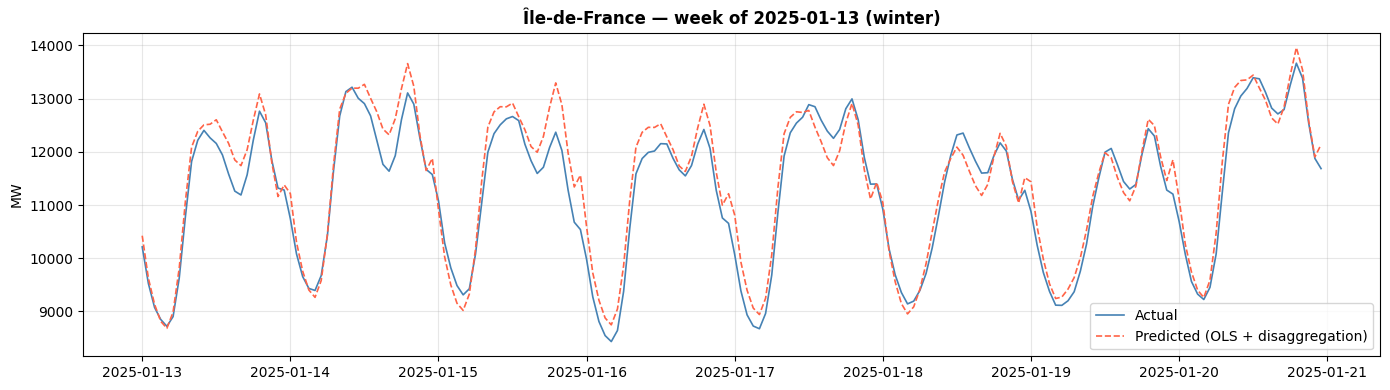

In [15]:
# Winter week example
region_ex = "Île-de-France"
start = f"{EVAL_YEAR}-01-13"
end   = f"{EVAL_YEAR}-01-20"

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(conso_h_eval.loc[start:end, region_ex],
        label="Actual", color="steelblue", lw=1.2)
ax.plot(hourly_pred_eval.loc[start:end, region_ex],
        label="Predicted (OLS + disaggregation)", color="tomato", lw=1.2, ls="--")
ax.set_title(f"{region_ex} — week of {start} (winter)", fontweight="bold")
ax.set_ylabel("MW")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

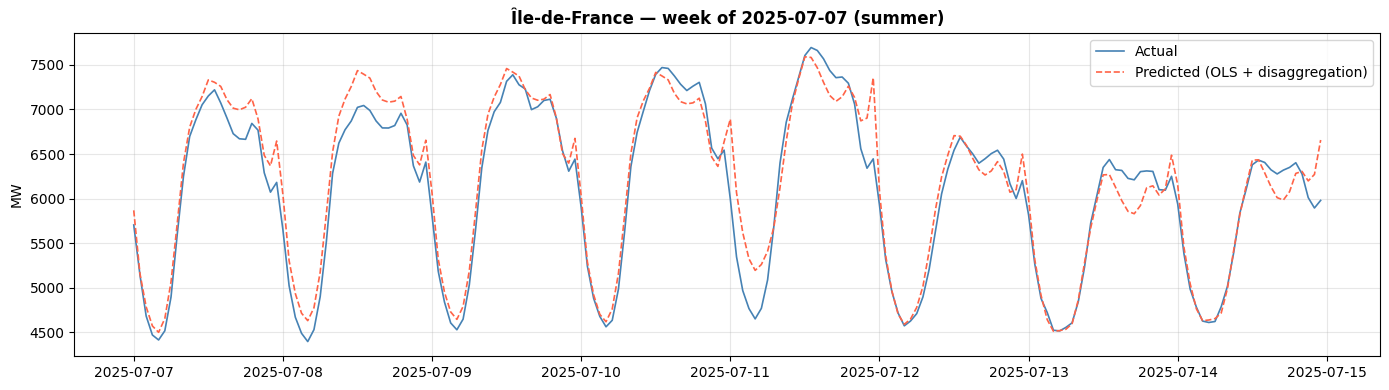

In [16]:
# Summer week example
start_ete = f"{EVAL_YEAR}-07-07"
end_ete   = f"{EVAL_YEAR}-07-14"

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(conso_h_eval.loc[start_ete:end_ete, region_ex],
        label="Actual", color="steelblue", lw=1.2)
ax.plot(hourly_pred_eval.loc[start_ete:end_ete, region_ex],
        label="Predicted (OLS + disaggregation)", color="tomato", lw=1.2, ls="--")
ax.set_title(f"{region_ex} — week of {start_ete} (summer)", fontweight="bold")
ax.set_ylabel("MW")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4b. Temperature residual analysis

How much of the hourly reconstruction error is driven by temperature?

- **(1)** Scatter + 1°C-bin mean: residual vs temperature — a flat cloud means the profiles already absorb the temperature shape well; a trend indicates that temperature-stratified profiles (step 2) could help.
- **(2)** MAE by temperature bin: where are errors largest? (cold waves, heat waves, mild weather?)
- **(3)** Mean residual by season × temperature: checks for season-temperature interaction.
- **(4)** R²(resid ~ T) by season × hour: which hours and seasons have temperature-driven disaggregation errors?

> **Note**: pass `temp_hourly` to `compute_residuals` for the temperature column to be available. If you don't have hourly temperatures, panels (1)–(4) will show a "Temperature not provided" message.

[load] conso_reg_hourly.csv : 13 timestamp(s) dupliqué(s) retirés (probablement changements d'heure)
[load] Conso : 2013-01-01 00:00:00 → 2026-01-01 23:00:00  |  113,963 lignes  |  12 régions
[load] temp_FR_hourly_era.csv : 16 timestamp(s) dupliqué(s) retirés (probablement changements d'heure)
[load] Temp  : 2010-01-01 01:00:00 → 2026-01-01 00:00:00  |  140,240 lignes  |  12 régions


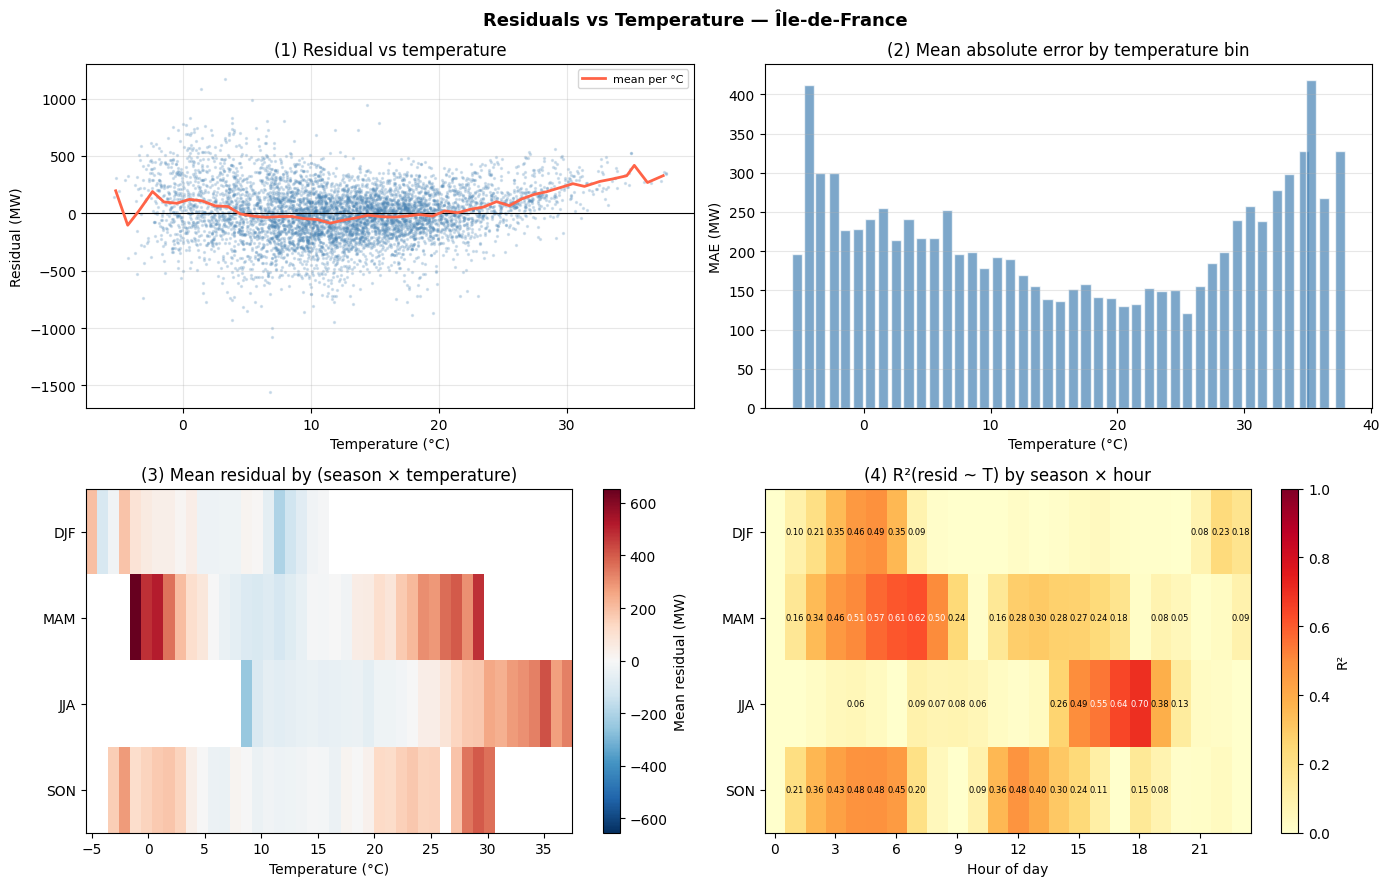


Temperature–residual correlation — Île-de-France
  R²(resid ~ T) overall : 0.0014  (weak temperature signal in disaggregation errors)
  Mean residual          : -0.00 MW
  MAE                    : 182.50 MW


In [17]:
# ── Load hourly temperature (optional but needed for the temperature analysis) ─
TEMP_HOURLY_PATH = "base_data/temp_era/temp_FR_hourly_era.csv"  # adjust path
_, temp_hourly = load_hourly_data(CONSO_HOURLY_PATH, TEMP_HOURLY_PATH)
  # set to actual DataFrame if you have hourly temperatures

# ── Analyse per region ────────────────────────────────────────────────────────
# Residuals here come from the disaggregation of ACTUAL daily totals
# (pure disaggregation error, independent of OLS daily error).
# To also include OLS daily error, replace conso_hourly with hourly_pred first.

region_ex = "Île-de-France"

res_df = compute_residuals(
    conso_hourly,          # actual hourly consumption (MW)
    profiles,
    region=region_ex,
    years=[EVAL_YEAR],
    temp_hourly=temp_hourly,
)

plot_residuals_vs_temperature(res_df, region=region_ex)

## Étape 5 — Agrégation nationale & évaluation finale

In [18]:
regions_communes = [r for r in hourly_pred_eval.columns if r in conso_h_eval.columns]

true_nat_h = conso_h_eval[regions_communes].sum(axis=1, min_count=1)
pred_nat_h = hourly_pred_eval[regions_communes].sum(axis=1)

common = true_nat_h.dropna().index.intersection(pred_nat_h.dropna().index)
err    = true_nat_h.loc[common] - pred_nat_h.loc[common]

rmse = float(np.sqrt((err**2).mean()))
mae  = float(err.abs().mean())
mape = float((err.abs() / true_nat_h.loc[common].abs()).mean() * 100)

print(f"=== National hourly evaluation — {EVAL_YEAR} ===")
print(f"  RMSE  : {rmse:>10,.0f} MW")
print(f"  MAE   : {mae:>10,.0f} MW")
print(f"  MAPE  : {mape:>10.2f} %")
print(f"  N     : {len(common):>10,} hours")

=== National hourly evaluation — 2025 ===
  RMSE  :      2,250 MW
  MAE   :      1,684 MW
  MAPE  :       3.35 %
  N     :      8,758 hours


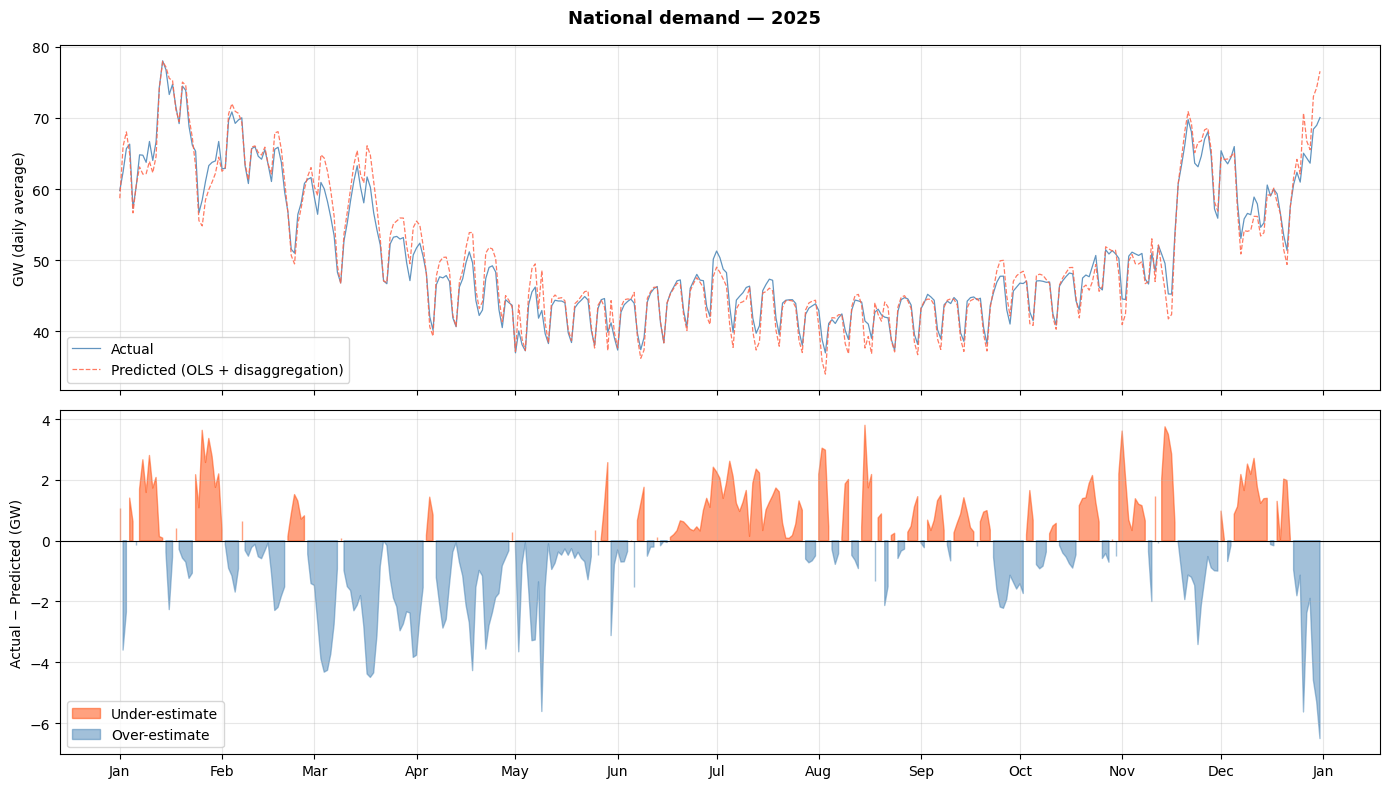

In [19]:
# National daily average curve (MW → GW)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f"National demand — {EVAL_YEAR}", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(true_nat_h.resample("D").mean() / 1000,
        label="Actual", color="steelblue", lw=0.9, alpha=0.85)
ax.plot(pred_nat_h.resample("D").mean() / 1000,
        label="Predicted (OLS + disaggregation)", color="tomato", lw=0.9, ls="--", alpha=0.85)
ax.set_ylabel("GW (daily average)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ecart = (true_nat_h - pred_nat_h).resample("D").mean() / 1000
ax.fill_between(ecart.index, ecart, 0,
                where=(ecart >= 0), color="orangered", alpha=0.5, label="Under-estimate")
ax.fill_between(ecart.index, ecart, 0,
                where=(ecart < 0),  color="steelblue", alpha=0.5, label="Over-estimate")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Actual − Predicted (GW)")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

In [20]:
# Final summary table
print("=== FULL PIPELINE SUMMARY ===")
print(f"\nStep 1 — Daily OLS (in-sample, {TRAIN_YEARS[0]}–{TRAIN_YEARS[-1]})")
print(metrics_daily[["RMSE", "MAPE_%"]].rename(columns={"MAPE_%": "MAPE (%)"})
      .assign(**{"level": "daily"}).to_string())

print(f"\nStep 2 — Daily OLS (out-of-sample, {EVAL_YEAR})")
# already printed in cells above

print(f"\nStep 4 — Full hourly pipeline (out-of-sample, {EVAL_YEAR})")
print(metrics_hourly[["RMSE", "MAPE_%"]].rename(columns={"MAPE_%": "MAPE (%)"}).to_string())

print(f"\nNational hourly: RMSE = {rmse:,.0f} MW | MAPE = {mape:.2f} %")

=== FULL PIPELINE SUMMARY ===

Step 1 — Daily OLS (in-sample, 2016–2024)
                             RMSE  MAPE (%)  level
Auvergne-Rhône-Alpes        242.2      2.62  daily
Bourgogne-Franche-Comté     125.6      4.41  daily
Bretagne                    132.3      3.90  daily
Centre-Val de Loire         122.4      4.85  daily
Grand Est                   213.9      3.61  daily
Hauts-de-France             208.9      3.11  daily
Normandie                   163.4      4.34  daily
Nouvelle-Aquitaine          240.4      4.14  daily
Occitanie                   205.9      3.86  daily
Pays de la Loire            138.0      3.57  daily
Provence-Alpes-Côte d'Azur  185.3      3.30  daily
Île-de-France               327.4      3.49  daily

Step 2 — Daily OLS (out-of-sample, 2025)

Step 4 — Full hourly pipeline (out-of-sample, 2025)
                             RMSE  MAPE (%)
region                                     
Auvergne-Rhône-Alpes        340.7      3.67
Bourgogne-Franche-Comté     148.8    

### 5b. Temperature residual analysis — full pipeline (eval year)

How much of the **end-to-end** error (OLS daily + disaggregation) is explained by temperature for `EVAL_YEAR`?

- **(1)** Scatter + 1°C-bin mean: reveals remaining temperature-driven bias after the full chain.
- **(2)** MAE by temperature bin: where does the combined error peak (cold waves, heat waves)?
- **(3)** Mean residual by season × temperature: season-temperature interaction in the combined error.
- **(4)** R²(resid ~ T) by season × hour: quantifies how much hourly error variance is still explained by temperature after OLS + disaggregation.

> Compare with §4b (pure disaggregation error): here the residuals include the OLS daily model error as well.

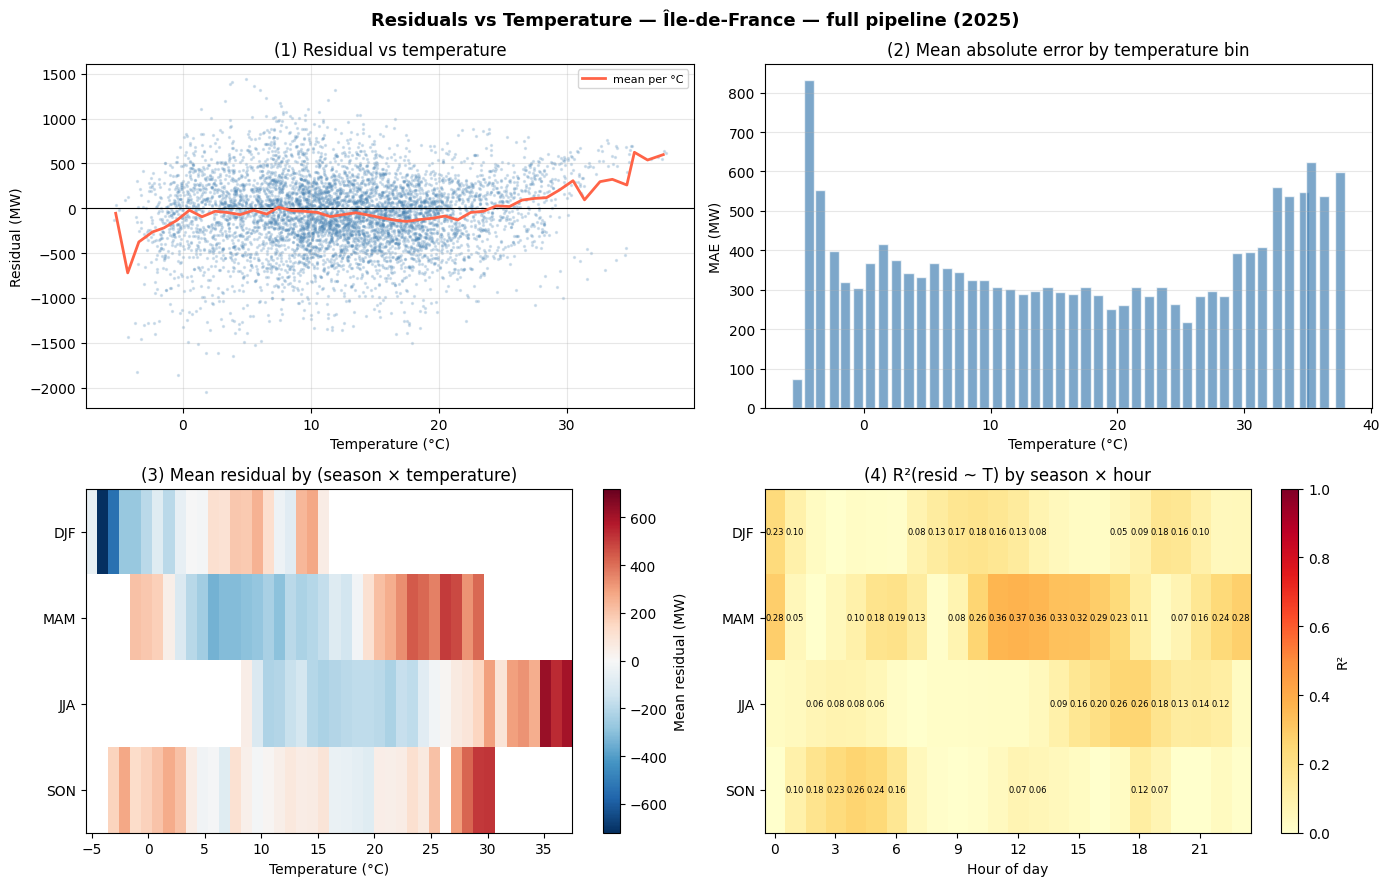


Temperature–residual correlation — Île-de-France — full pipeline (2025)
  R²(resid ~ T) overall : 0.0034  (weak temperature signal in disaggregation errors)
  Mean residual          : -62.55 MW
  MAE                    : 315.81 MW


In [21]:
from hourly_disaggregation import MONTH_TO_SEASON

region_5b = region_ex  # reuse region_ex defined in §4 above — change as needed

# Full-pipeline residuals: actual hourly vs OLS-predicted + disaggregated
y_full  = conso_h_eval[region_5b]
yp_full = hourly_pred_eval[region_5b]

res_full = pd.DataFrame({"y": y_full, "y_pred": yp_full}).dropna()
res_full["resid"]  = res_full["y"] - res_full["y_pred"]
res_full["hour"]   = res_full.index.hour
res_full["month"]  = res_full.index.month
res_full["saison"] = res_full["month"].map(MONTH_TO_SEASON)

if temp_hourly is not None and region_5b in temp_hourly.columns:
    res_full["T"] = temp_hourly[region_5b].reindex(res_full.index)

plot_residuals_vs_temperature(
    res_full,
    region=f"{region_5b} — full pipeline ({EVAL_YEAR})",
)